In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cyberbullying-classification/cyberbullying_tweets.csv


## Step 1: Load the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("/kaggle/input/cyberbullying-classification/cyberbullying_tweets.csv")
data.shape

(47692, 2)

In [4]:
data.columns

Index(['tweet_text', 'cyberbullying_type'], dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


So there are no null values and f1-score is pretty good

In [6]:
data.shape

(47692, 2)

Okay this dataset has only 2 columns, one is feature and other is target

In [7]:
data.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [8]:
data.sample(3)

,tweet_text,cyberbullying_type
25385,http://t.co/ZxbZV39jru: Maine #coon Bonnie cat...,other_cyberbullying
7194,¿Crees que el bullying deberia ser considerado...,not_cyberbullying
7460,@logicalmind11 http://t.co/PQtPUrEL3O,not_cyberbullying


In [9]:
data.cyberbullying_type.value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

In [10]:
# splitting the data as targets and features

X = data['tweet_text']
y = data['cyberbullying_type']

X.shape, y.shape

((47692,), (47692,))

In [11]:
data.describe()

,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,RT @sailorhg: the intro for my hardware hackin...,religion
freq,2,7998


In [12]:
data.isnull().sum()

# So there are no null values

tweet_text            0
cyberbullying_type    0
dtype: int64

## Step 2: Precoss the data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(
    stop_words = 'english'
)

X = vec.fit_transform(X)

In [14]:
X.shape

(47692, 59970)

Now the feature data has been vectorized, its ready to train with. But labels are not yet vectorized, lets do it

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [30]:
y.shape

(47692,)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((38153, 59970), (38153,), (9539, 59970), (9539,))

In [35]:
import numpy as np
y_train = np.array(y_train)
y_test = np.array(y_test)

y_train.shape, y_test.shape

((38153,), (9539,))

In [47]:
print(type(X_test), type(X_train)) # if it shows scipy then convert to numpoy array

X_train = np.array(X_train)
X_test = np.array(X_test)


<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>


## Step 3: Train the Model

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, solver="liblinear")
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000, solver='liblinear')

In [48]:
y_pred = lr.predict(X_test)

In [49]:
print(pred[0])
print(y_test[0])

1
1


Yup it is predicting correctly

## Step 4: Evaluate the model

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.8311143725757417

Classification Report:

                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1603
          ethnicity       0.98      0.96      0.97      1603
             gender       0.91      0.82      0.87      1531
  not_cyberbullying       0.60      0.58      0.59      1624
other_cyberbullying       0.62      0.70      0.66      1612
           religion       0.94      0.95      0.94      1566

           accuracy                           0.83      9539
          macro avg       0.84      0.83      0.83      9539
       weighted avg       0.84      0.83      0.83      9539



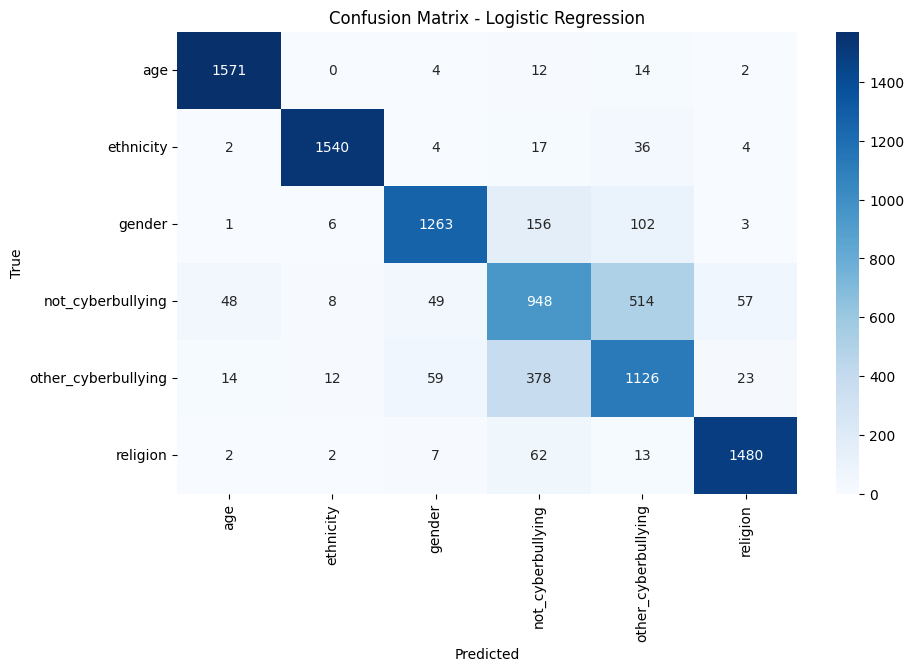

In [53]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [55]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))


Accuracy: 0.7584652479295524

Classification Report:

                     precision    recall  f1-score   support

                age       0.71      0.99      0.82      1603
          ethnicity       0.85      0.90      0.87      1603
             gender       0.80      0.87      0.83      1531
  not_cyberbullying       0.67      0.36      0.47      1624
other_cyberbullying       0.66      0.48      0.55      1612
           religion       0.80      0.98      0.88      1566

           accuracy                           0.76      9539
          macro avg       0.75      0.76      0.74      9539
       weighted avg       0.75      0.76      0.74      9539



In [57]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Logistic Regression Accuracy: 0.8311143725757417
Naive Bayes Accuracy: 0.7584652479295524


In [65]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np

df = pd.read_csv("/kaggle/input/cyberbullying-classification/cyberbullying_tweets.csv")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['cyberbullying_type'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['tweet_text'], y, test_size=0.2, random_state=42)

# Vectorize
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

# ensure y is 1D numpy array
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

# Train model
lr = LogisticRegression(max_iter=1000, solver="liblinear")
lr.fit(X_train, y_train)

preds = lr.predict(X_test)
